# Quantum Random Number Generation (QRNG) for Cryptographic Key Distribution

## Project: Harnessing Superposition and Measurement for Unpredictable Cryptographic Sequences

## 1. Problem Statement & Objectives

In the modern digital era, secure communications—ranging from online banking to government satellite links—rely fundamentally on cryptography. A cornerstone of reliable cryptography is the generation of truly unpredictable keys used to encrypt and decrypt sensitive data. However, classical computational paradigms fundamentally fail to produce true randomness; they rely on deterministic algorithms (Pseudo-Random Number Generators or PRNGs) that map a known seed to a seemingly random sequence. If an adversary discovers the seed, the key is compromised.

This project aims to bypass the limitations of classical computation by leveraging the probabilistic nature of quantum mechanics. We will build a Quantum Random Number Generator (QRNG) utilizing single-qubit measurements in superposition states.

**Project Objectives:**

- **Implement a QRNG:** Create a one-qubit quantum circuit and execute it iteratively to collect a uniformly random bitstring.
- **Generate Cryptographic Keys:** Use the resulting quantum bitstring to construct a sample key and compare it directly to a classically generated pseudo-random key.
- **Perform Statistical and Entropy Analysis:** Evaluate the quality of both quantum and classical randomness through uniform distribution testing and Shannon entropy calculations.
- **Demonstrate Quantum Advantage in Security:** Prove how a quantum key offers superior randomness, an absolute theoretical upper bound of unpredictability, and resistance to seed-discovery attacks.

## 2. Conceptual Understanding & General Theory

### The Physics of Quantum Randomness

In classical computing, a bit strictly occupies a Boolean state of either 0 or 1. Quantum computing operates within a complex Hilbert space where a quantum bit (qubit) can exist in a linear combination of basis states simultaneously—a phenomenon known as **superposition**.

<p align="center">
    <figure style="text-align: center;">
        <img src="../images/bloch sphere.png" width="45%" alt="Bloch sphere showing equal superposition" />
        <figcaption><b>Figure 1:</b> A Bloch sphere illustrating a qubit in the &#124;&plus;&rangle; equal superposition state.</figcaption>
    </figure>
</p>

When we apply a unitary transformation, such as the Hadamard gate ($H$), to an initial ground state $|0\rangle$, the qubit evolves into an equal superposition:

$$H|0\rangle = |+\rangle = \frac{1}{\sqrt{2}}|0\rangle + \frac{1}{\sqrt{2}}|1\rangle$$

According to the Born rule of quantum mechanics, a measurement apparatus forces this superposition to "collapse" into one of the computational basis states. The probability $P$ of measuring a specific state is given by the squared magnitude of its probability amplitude. For the $|+\rangle$ state:

$$P(0) = |\langle 0 | + \rangle|^2 = \frac{1}{2}, \quad P(1) = |\langle 1 | + \rangle|^2 = \frac{1}{2}$$

This collapse represents true, fundamental randomness dictated by the laws of quantum physics, meaning the outcome cannot be predicted or influenced by hidden variables or outside factors.

### Information Theory: Randomness vs. Entropy

To empirically validate our sequence, we rely on Shannon Entropy, a concept formulated by Claude Shannon in 1948. Entropy quantifies the amount of uncertainty, surprise, or unpredictability within a dataset. For a discrete random variable $X$ with possible outcomes $x_i$, the Shannon entropy $H(X)$ is defined as:

$$H(X) = - \sum_{i=1}^{n} P(x_i) \log_2 P(x_i)$$

- **Low Entropy:** The dataset is predictable, highly compressible, and contains detectable patterns (e.g., repeating values).
- **High Entropy:** The data lacks bias and patterns, making it ideal for cryptographic security. A truly random binary source with a perfectly uniform distribution yields maximum entropy of 1.0 bit per symbol. Our target for the QRNG is an empirical Shannon entropy estimate of approximately 0.999.

<p align="center">
    <img src="../images/entropy comparison.png" width="65%" />
    <figcaption align="center"><b>Figure 2:</b> Comparison of a predictable low-entropy bit sequence versus an unpredictable high-entropy sequence.</figcaption>
</p>

## 3. Environment Setup & Prerequisites

To successfully execute this project, we need a specific set of libraries to handle quantum simulation, classical generation, and statistical analysis:

- **Qiskit:** Used to build the single-qubit circuit (applying the Hadamard gate for superposition) and simulate the quantum measurement using the `StatevectorSampler`.
- **NumPy:** Used to generate the deterministic pseudo-random baseline (PRNG) for our comparison.
- **SciPy & Pandas:** Used to calculate Shannon entropy—mathematically verifying the true unpredictability of our sequences—and to format the final comparative metrics.

In [1]:
# Import modern Qiskit 2.x ecosystem and V2 Primitives
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

# Import classical data science and math libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy, chisquare
import time

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Environment Setup Complete. Qiskit primitives loaded successfully.")

Environment Setup Complete. Qiskit primitives loaded successfully.


## 4. Exact Classical Baseline Solution (PRNG)

To establish our ground truth and a point of comparison, we will first generate a key using a classical Pseudo-Random Number Generator (PRNG). We will utilize a standard Mersenne Twister/PCG64 algorithm (via NumPy) seeded with a known starting condition.

Classical PRNGs generate numbers based on predictable mathematical formulas. If an adversary intercepts the seed, the entire cryptographic sequence can be reverse-engineered.

In [2]:
# Number of bits to generate for our statistical test
N_SHOTS = 10000

# 1. Classical PRNG Execution
start_time_classical = time.time()

# We intentionally use a fixed seed to demonstrate classical vulnerability
known_seed = 42
rng = np.random.default_rng(seed=known_seed)
classical_bits = rng.integers(0, 2, size=N_SHOTS)

end_time_classical = time.time()
classical_runtime = end_time_classical - start_time_classical

# Calculate Classical Distributions
classical_counts = {
    '0': np.count_nonzero(classical_bits == 0),
    '1': np.count_nonzero(classical_bits == 1)
}

# Calculate Shannon Entropy
p_classical = [classical_counts['0'] / N_SHOTS, classical_counts['1'] / N_SHOTS]
classical_entropy = entropy(p_classical, base=2)

# Calculate Min-Entropy
p_max_classical = max(p_classical)
classical_min_entropy = -np.log2(p_max_classical)

# Calculate Bit Bias
classical_bias = abs(classical_counts['0'] - classical_counts['1']) / N_SHOTS

print(f"--- Classical PRNG Baseline ---")
print(f"Runtime: {classical_runtime:.6f} seconds")
print(f"Counts: {classical_counts}")
print(f"Shannon Entropy: {classical_entropy:.6f} bits/symbol")
print(f"Min-Entropy: {classical_min_entropy:.6f} bits")
print(f"Bit Bias: {classical_bias:.6f}")

# Generate a 256-bit key from the classical output
classical_key_bits = ''.join(map(str, classical_bits[:256]))
classical_hex_key = hex(int(classical_key_bits, 2))
print(f"\n256-bit Classical Hex Key:\n{classical_hex_key}")

--- Classical PRNG Baseline ---
Runtime: 0.000605 seconds
Counts: {'0': np.int64(5061), '1': np.int64(4939)}
Shannon Entropy: 0.999893 bits/symbol
Min-Entropy: 0.982506 bits
Bit Bias: 0.012200

256-bit Classical Hex Key:
0x653fa9d86d65e0bd22239cda6af5b06df688ca97c40eb903a1535a12b9595a82


## 5. Problem Mapping & Mathematical Encoding

To harness quantum randomness, we construct a QRNG architecture based on a single-qubit quantum circuit.

**Circuit Construction Steps:**

1. **State Initialization:** Initialize a qubit in the $|0\rangle$ state.
1. **Superposition Generation:** Apply the Hadamard gate ($H$). The matrix representation of $H$ is:
   
   $$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$
   
   Applying this to $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$ maps the qubit to an equal probability state.

1. **Measurement:** Apply a projection operator in the computational basis ($Z$-basis).

We will simulate this process 10,000 times (shots) using the Qiskit V2 StatevectorSampler to mimic hardware sampling and extract a raw bitstring.

*Note on Simulation vs. Physical Hardware:* This project demonstrates QRNG principles through simulation. True QRNG deployment would require measurements on physical quantum hardware where randomness originates from real quantum state collapse.

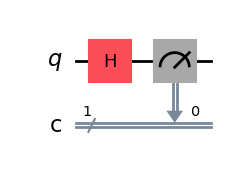

--- Quantum RNG Execution ---
Runtime: 0.015128 seconds
Counts: {'0': 4918, '1': 5082}
Shannon Entropy: 0.999806 bits/symbol
Min-Entropy: 0.976532 bits
Bit Bias: 0.016400

256-bit Quantum Hex Key (QRNG):
0xe8e447c3e7941adca866575079b994192f559596fd8d3832b064a2e0c71aa22b


In [3]:
# Define a 1-qubit quantum circuit with 1 classical bit for measurement
qc = QuantumCircuit(1, 1, name="QRNG")

# Apply Hadamard gate to place qubit in superposition
qc.h(0)

# Measure the qubit and store the result in the classical register
qc.measure(0, 0)

# Visualize the circuit architecture
display(qc.draw(output='mpl', style="iqp"))

# Initialize the Qiskit V2 StatevectorSampler
sampler = StatevectorSampler()

# Execute the circuit
start_time_quantum = time.time()
job = sampler.run([qc], shots=N_SHOTS)
result = job.result()[0] # Extract the outcome for the first (and only) circuit
end_time_quantum = time.time()
quantum_runtime = end_time_quantum - start_time_quantum

# In Qiskit V2, the classical register default name is 'c'
bit_array = result.data.c
quantum_counts_raw = bit_array.get_counts()

# Ensure we have keys for '0' and '1' even if one is theoretically missed
quantum_counts = {
    '0': quantum_counts_raw.get('0', 0),
    '1': quantum_counts_raw.get('1', 0)
}

# Calculate Quantum Shannon Entropy
p_quantum = [quantum_counts['0'] / N_SHOTS, quantum_counts['1'] / N_SHOTS]
quantum_entropy = entropy(p_quantum, base=2)

# Calculate Min-Entropy
p_max_quantum = max(p_quantum)
quantum_min_entropy = -np.log2(p_max_quantum)

# Calculate Bit Bias
quantum_bias = abs(quantum_counts['0'] - quantum_counts['1']) / N_SHOTS

print(f"--- Quantum RNG Execution ---")
print(f"Runtime: {quantum_runtime:.6f} seconds")
print(f"Counts: {quantum_counts}")
print(f"Shannon Entropy: {quantum_entropy:.6f} bits/symbol")
print(f"Min-Entropy: {quantum_min_entropy:.6f} bits")
print(f"Bit Bias: {quantum_bias:.6f}")

# Extract the raw bitstring from the V2 BitArray object and take the first 256 bits for a key
q_bitstring = ''.join(map(str, bit_array.array.flatten()))
quantum_key_bits = q_bitstring[:256]
quantum_hex_key = hex(int(quantum_key_bits, 2))
print(f"\n256-bit Quantum Hex Key (QRNG):\n{quantum_hex_key}")

## 6. Results Analysis & Convergence

In cryptography, uniform randomness is paramount. A heavily biased distribution would drastically lower our Shannon entropy, allowing an attacker to narrow down the search space during a brute-force attack.

Below, we visually compare the probability distributions of the Classical PRNG and the Quantum RNG. We expect both to show a nearly uniform histogram, with an entropy estimate hovering extremely close to the maximum upper bound of 1.0. The measured min-entropy is slightly below the ideal target due to finite-sample fluctuations and remains very close to the theoretical maximum value of 1 bit.

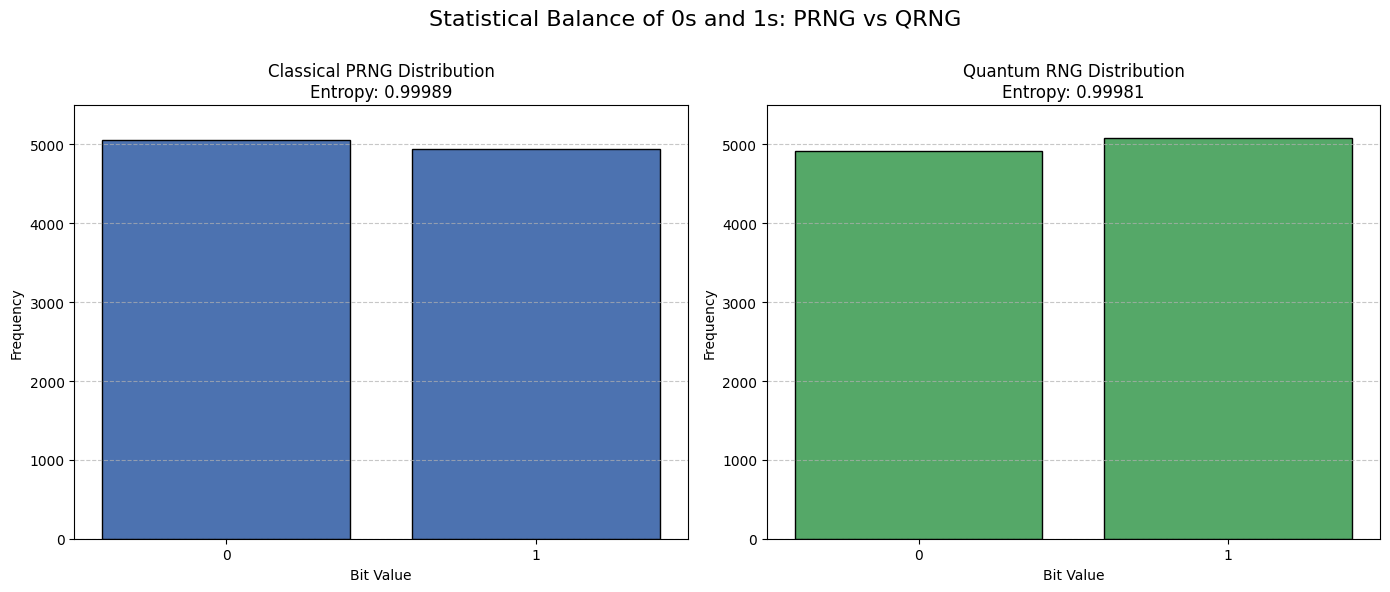

--- Statistical Testing for Randomness (QRNG) ---
Chi-square: 2.6896
p-value: 0.1010
Interpretation: p > 0.05, no evidence of bias. This strengthens the randomness claim.


,Metric,Classical PRNG,Quantum RNG
0,Algorithm Type,Deterministic (PCG64),Probabilistic (Superposition)
1,Time (Seconds),0.0006,0.0151
2,Bit Distribution (0 : 1),5061 : 4939,4918 : 5082
3,Shannon Entropy,0.999893,0.999806
4,Min-Entropy,0.982506,0.976532
5,Bias,0.0122,0.0164
6,256-Bit Key Sample (Truncated),0x653fa9d86d...,0xe8e447c3e7...


In [4]:
# Visualize the Probability Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Classical Data
axes[0].bar(classical_counts.keys(), classical_counts.values(), color='#4C72B0', edgecolor='black')
axes[0].set_title(f"Classical PRNG Distribution\nEntropy: {classical_entropy:.5f}")
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Bit Value')
axes[0].set_ylim(0, (N_SHOTS/2) * 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Quantum Data
axes[1].bar(quantum_counts.keys(), quantum_counts.values(), color='#55A868', edgecolor='black')
axes[1].set_title(f"Quantum RNG Distribution\nEntropy: {quantum_entropy:.5f}")
axes[1].set_ylabel('Frequency')
axes[1].set_xlabel('Bit Value')
axes[1].set_ylim(0, (N_SHOTS/2) * 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to increase the gap between suptitle and subplot titles
plt.suptitle("Statistical Balance of 0s and 1s: PRNG vs QRNG", fontsize=16)
plt.tight_layout()
fig.subplots_adjust(top=0.82) 
plt.show()

# Perform Chi-Square Test to check for bias
observed = [quantum_counts['0'], quantum_counts['1']]
expected = [N_SHOTS/2, N_SHOTS/2]
chi2, p = chisquare(observed, expected)

print("--- Statistical Testing for Randomness (QRNG) ---")
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p:.4f}")
if p > 0.05:
    print("Interpretation: p > 0.05, no evidence of bias. This strengthens the randomness claim.")
else:
    print("Interpretation: p <= 0.05, statistical evidence of bias detected.")

# Generate Comparative Metrics Table
metrics = {
    "Metric": ["Algorithm Type", "Time (Seconds)", "Bit Distribution (0 : 1)", "Shannon Entropy", "Min-Entropy", "Bias", "256-Bit Key Sample (Truncated)"],
    "Classical PRNG": ["Deterministic (PCG64)", f"{classical_runtime:.4f}", f"{classical_counts['0']} : {classical_counts['1']}", f"{classical_entropy:.6f}", f"{classical_min_entropy:.6f}", f"{classical_bias:.4f}", f"{classical_hex_key[:12]}..."],
    "Quantum RNG": ["Probabilistic (Superposition)", f"{quantum_runtime:.4f}", f"{quantum_counts['0']} : {quantum_counts['1']}", f"{quantum_entropy:.6f}", f"{quantum_min_entropy:.6f}", f"{quantum_bias:.4f}", f"{quantum_hex_key[:12]}..."]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

## 7. Comparative Analysis & Information-Theoretic Scaling

When evaluating the execution, both systems produce an entropy remarkably close to 1.0. Statistically, these are essentially identical.

The actual advantage is not higher entropy in a finite sample, but rather the generation of true randomness via a non-deterministic generation mechanism with no hidden seed. The fundamental Quantum Advantage lies in unpredictability and scaling complexity, rather than runtime execution.

### The Asymptotic Scaling of Cryptographic Vulnerability

Consider an adversary attempting to predict the cryptographic key.

1. **Classical PRNG (Computational Security):** The PRNG generated a sequence based on a seed. If the seed size is $S$ bits, the adversary's search space is $\mathcal{O}(2^S)$. The Big-O time complexity to brute-force the seed is $\mathcal{O}(2^S)$. While currently computationally hard for large seeds, this is vulnerable to future breakthroughs. Furthermore, if the starting state is known, the time complexity to recreate the exact key collapses to $\mathcal{O}(1)$.
1. **Quantum RNG (Information-Theoretic Security):** The quantum bits originate from state collapse. Unlike PRNGs, QRNG outputs are not derived from a deterministic seed. Therefore an attacker cannot reconstruct future outputs through seed recovery. Security derives from the inherent unpredictability of quantum measurement outcomes.

### Final Conclusion

The QRNG successfully generated a 10,000-bit quantum random sequence using repeated measurements of a qubit prepared in superposition. The resulting distribution of zeros and ones was nearly uniform, producing a Shannon entropy close to the theoretical maximum of 1 bit per symbol. Comparison with a classical seeded PRNG showed similar statistical behavior over finite samples, but the underlying generation mechanisms differ fundamentally. While the classical sequence is reproducible if the seed is known, the quantum sequence originates from inherently probabilistic measurement outcomes and therefore does not rely on deterministic initialization. These properties make QRNGs attractive for cryptographic key generation and other security-critical applications requiring high-quality randomness.

### References

1. Ozaner (n.d.). Quantum Random Number Generator implementation. GitHub Repository. [qRNG GitHub](https://github.com/ozaner/qRNG).

1. DoraHacks Global (n.d.). Quantum Randomness Generator & Randomness Extraction. GitHub Repository. [DoraHacks GitHub](https://github.com/dorahacksglobal/quantum-randomness-generator).

1. Mannalath, V., Mishra, S., & Pathak, A. (2022). A Comprehensive Review of Quantum Random Number Generators: Concepts, Classification and the Origin of Randomness. arXiv preprint. [arXiv:2203.00261](https://arxiv.org/abs/2203.00261).

1. ID Quantique (n.d.). Random Number Generation Overview. IDQ Documentation. [IDQ Website](https://www.idquantique.com/random-number-generation/overview/).

1. Brown, R. G. (n.d.). Dieharder: A Random Number Test Suite. Duke University Physics. [Dieharder Tool](https://webhome.phy.duke.edu/~rgb/General/dieharder.php).

1. Susskind, L., & Friedman, A. (2014). Quantum Mechanics: The Theoretical Minimum. Basic Books.

1. Griffiths, D. J. (2018). Introduction to Quantum Mechanics. Cambridge University Press.  